In [24]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import seaborn as sns

# Set style for better-looking plots
plt.style.use('default')
sns.set_palette("husl")

# Read the CSV file
df = pd.read_csv('us_retail_sales.csv')

# Melt the dataframe to convert months to a single column
months = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN','JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']

# Create a melted dataframe for easier plotting
melted_data = []

for _, row in df.iterrows():
    # Convert year to integer to avoid floating point in date string
    year = int(row['YEAR'])
    for month in months:
        if pd.notna(row[month]):  # Only include non-null values
            melted_data.append({
                'Year': year,
                'Month': month,
                'Sales': row[month],
                'Date': f"{year}-{months.index(month)+1:02d}"
            })

melted_df = pd.DataFrame(melted_data)

# Convert to datetime after ensuring proper format
melted_df['Date'] = pd.to_datetime(melted_df['Date'])

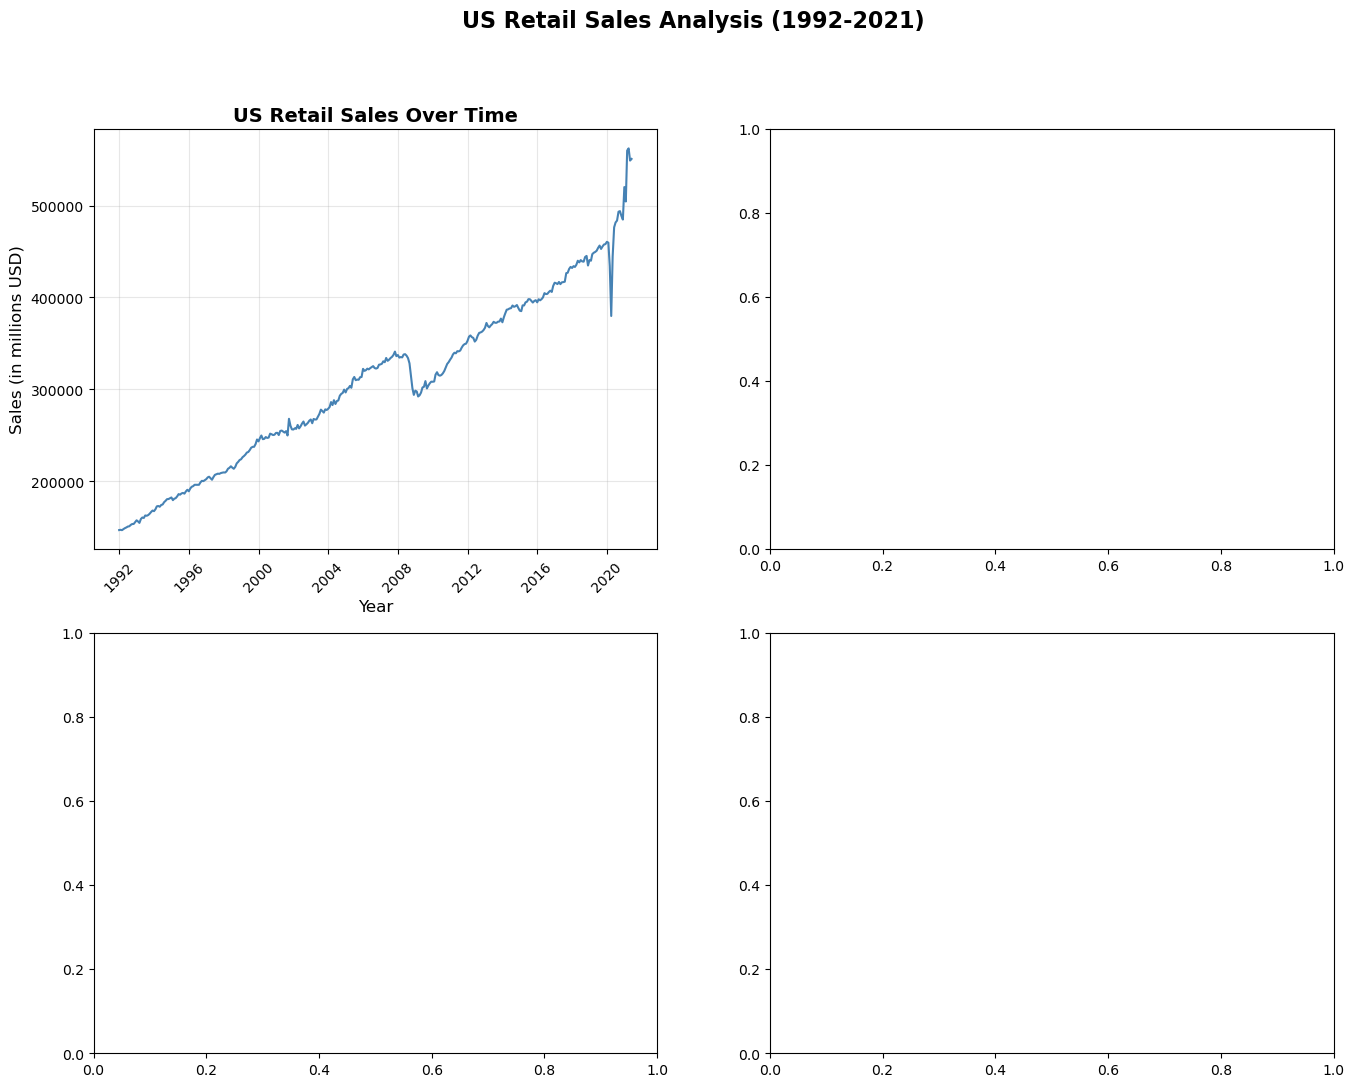

In [25]:
# Create the main plot

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

fig.suptitle('US Retail Sales Analysis (1992-2021)', fontsize=16, fontweight='bold')

# Plot 1: Time series of retail sales
ax1.plot(melted_df['Date'], melted_df['Sales'], linewidth=1.5, color='steelblue')
ax1.set_title('US Retail Sales Over Time', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Sales (in millions USD)', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)


In [26]:
# Add trend line
z = np.polyfit(range(len(melted_df)), melted_df['Sales'], 1)
p = np.poly1d(z)
ax1.plot(melted_df['Date'], p(range(len(melted_df))), "r--", alpha=0.8, linewidth=2, label='Trend Line')
ax1.legend()


In [27]:
# Plot 2: Seasonal patterns (average by month)

monthly_avg = melted_df.groupby('Month')['Sales'].mean()

month_order = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN','JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']

monthly_avg = monthly_avg.reindex(month_order)


ax2.bar(monthly_avg.index, monthly_avg.values, color='lightcoral', alpha=0.7)
ax2.set_title('Average Retail Sales by Month', fontsize=14, fontweight='bold')
ax2.set_xlabel('Month', fontsize=12)
ax2.set_ylabel('Average Sales (in millions USD)', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3, axis='y')


In [31]:
# Plot 3: Year-over-year growth rate

yearly_sales = df.set_index('YEAR')[months].sum(axis=1)
growth_rate = yearly_sales.pct_change() * 100

 
ax3.bar(growth_rate.index[1:], growth_rate.values[1:],
        color=['green' if x > 0 else 'red' for x in growth_rate.values[1:]], alpha=0.7)

ax3.set_title('Year-over-Year Growth Rate', fontsize=14, fontweight='bold')
ax3.set_xlabel('Year', fontsize=12)
ax3.set_ylabel('Growth Rate (%)', fontsize=12)
ax3.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis='x', rotation=45)

In [32]:
# Plot 4: Sales distribution by decade

melted_df['Decade'] = (melted_df['Year'] // 10) * 10

decade_sales = melted_df.groupby('Decade')['Sales'].mean()

 
ax4.pie(decade_sales.values, labels=[f"{int(d)}s" for d in decade_sales.index],

        autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightgreen', 'lightyellow'])

ax4.set_title('Average Sales Distribution by Decade', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Print key observations

print("=" * 60)
print("KEY OBSERVATIONS FROM US RETAIL SALES DATA (1992-2021)")
print("=" * 60)


# Overall trend
total_growth = ((yearly_sales.iloc[-1] - yearly_sales.iloc[0]) / yearly_sales.iloc[0]) * 100
print(f"\n1. OVERALL TREND:")
print(f"   • Total growth from 1992 to 2020: {total_growth:.1f}%")
print(f"   • Average annual growth rate: {total_growth/28:.1f}%")

 

# Seasonal patterns
peak_month = monthly_avg.idxmax()
low_month = monthly_avg.idxmin()
seasonal_variation = ((monthly_avg.max() - monthly_avg.min()) / monthly_avg.mean()) * 100
 

print(f"\n2. SEASONAL PATTERNS:")
print(f"   • Peak sales month: {peak_month} (${monthly_avg.max():.0f}M average)")
print(f"   • Lowest sales month: {low_month} (${monthly_avg.min():.0f}M average)")
print(f"   • Seasonal variation: {seasonal_variation:.1f}% from average")

# Economic events impact
print(f"\n3. MAJOR ECONOMIC EVENTS IMPACT:")
print(f"   • 2008 Financial Crisis: {growth_rate.loc[2008]:.1f}% growth (recession year)")
print(f"   • 2009 Recovery: {growth_rate.loc[2009]:.1f}% growth")
print(f"   • 2020 COVID-19 Impact: {growth_rate.loc[2020]:.1f}% growth (pandemic year)")

<Figure size 640x480 with 0 Axes>

KEY OBSERVATIONS FROM US RETAIL SALES DATA (1992-2021)

1. OVERALL TREND:
   • Total growth from 1992 to 2020: 79.9%
   • Average annual growth rate: 2.9%

2. SEASONAL PATTERNS:
   • Peak sales month: JUN ($311407M average)
   • Lowest sales month: JUL ($304375M average)
   • Seasonal variation: 2.3% from average

3. MAJOR ECONOMIC EVENTS IMPACT:
   • 2008 Financial Crisis: -1.7% growth (recession year)
   • 2009 Recovery: -8.0% growth
   • 2020 COVID-19 Impact: 3.1% growth (pandemic year)


In [33]:
# Volatility analysis
std_dev = growth_rate.std()
print(f"\n4. VOLATILITY:")
print(f"   • Standard deviation of growth rates: {std_dev:.1f}%")
print(f"   • Most volatile year: {growth_rate.abs().idxmax()} ({growth_rate.loc[growth_rate.abs().idxmax()]:.1f}%)")

# Recent trends
recent_growth = growth_rate.loc[2015:2020].mean()
print(f"\n5. RECENT TRENDS (2015-2020):")
print(f"   • Average growth rate: {recent_growth:.1f}%")
print(f"   • 2020 showed resilience despite pandemic challenges")
print(f"\n6. DATA COMPLETENESS:")
print(f"   • Data available through June 2021")
print(f"   • Consistent monthly reporting from 1992-2020")
print("=" * 60)


4. VOLATILITY:
   • Standard deviation of growth rates: 9.1%
   • Most volatile year: 2021 (-41.8%)

5. RECENT TRENDS (2015-2020):
   • Average growth rate: 3.1%
   • 2020 showed resilience despite pandemic challenges

6. DATA COMPLETENESS:
   • Data available through June 2021
   • Consistent monthly reporting from 1992-2020


In [38]:
# ============================================================================
# DATA SPLITTING: Training and Test Sets
# ============================================================================
# Define the test period: July 2020 - June 2021 (last complete year of data)

test_start_date = pd.to_datetime('2020-07-01')
test_end_date = pd.to_datetime('2021-06-30')

# Split the data
train_df = melted_df[melted_df['Date'] < test_start_date].copy()
test_df = melted_df[(melted_df['Date'] >= test_start_date) & (melted_df['Date'] <= test_end_date)].copy()

print("=" * 80)
print("DATA SPLITTING SUMMARY")
print("=" * 80)

print(f"Original dataset: {len(melted_df)} data points ({melted_df['Date'].min().strftime('%Y-%m')} to {melted_df['Date'].max().strftime('%Y-%m')})")

print(f"Training set: {len(train_df)} data points ({train_df['Date'].min().strftime('%Y-%m')} to {train_df['Date'].max().strftime('%Y-%m')})")

print(f"Test set: {len(test_df)} data points ({test_df['Date'].min().strftime('%Y-%m')} to {test_df['Date'].max().strftime('%Y-%m')})")

print(f"Training period: {train_df['Date'].min().strftime('%B %Y')} to {train_df['Date'].max().strftime('%B %Y')}")

print(f"Test period: {test_df['Date'].min().strftime('%B %Y')} to {test_df['Date'].max().strftime('%B %Y')}")
print("=" * 80)

# Save the split datasets to CSV files
train_df.to_csv('retail_sales_train.csv', index=False)
test_df.to_csv('retail_sales_test.csv', index=False)
print("✓ Training data saved to: retail_sales_train.csv")
print("✓ Test data saved to: retail_sales_test.csv")
print()

DATA SPLITTING SUMMARY
Original dataset: 354 data points (1992-01 to 2021-06)
Training set: 342 data points (1992-01 to 2020-06)
Test set: 12 data points (2020-07 to 2021-06)
Training period: January 1992 to June 2020
Test period: July 2020 to June 2021
✓ Training data saved to: retail_sales_train.csv
✓ Test data saved to: retail_sales_test.csv



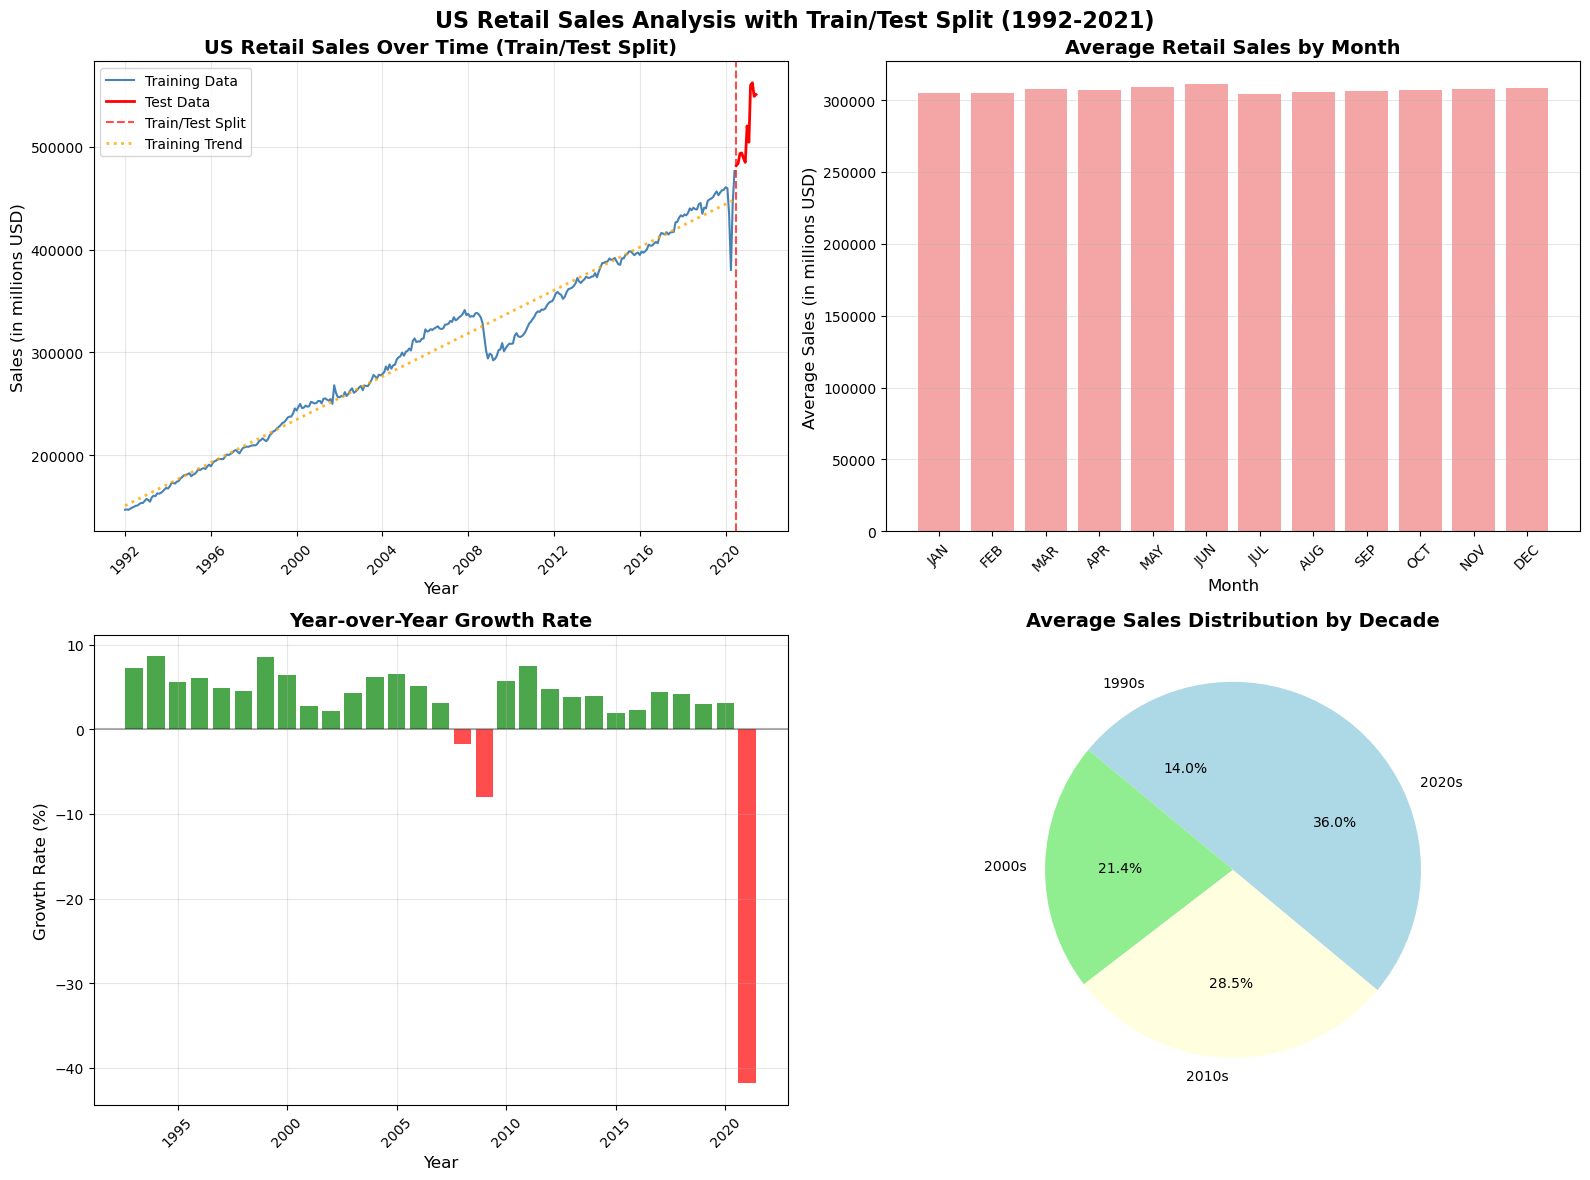

In [39]:
# Create the main plot with train/test visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('US Retail Sales Analysis with Train/Test Split (1992-2021)', fontsize=16, fontweight='bold')

# Plot 1: Time series of retail sales with train/test split highlighted
ax1.plot(train_df['Date'], train_df['Sales'], linewidth=1.5, color='steelblue', label='Training Data')
ax1.plot(test_df['Date'], test_df['Sales'], linewidth=2, color='red', label='Test Data')
ax1.axvline(x=test_start_date, color='red', linestyle='--', alpha=0.7, label='Train/Test Split')
ax1.set_title('US Retail Sales Over Time (Train/Test Split)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Sales (in millions USD)', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)
ax1.legend()

# Add trend line for training data only
if len(train_df) > 0:
    z = np.polyfit(range(len(train_df)), train_df['Sales'], 1)
    p = np.poly1d(z)
    ax1.plot(train_df['Date'], p(range(len(train_df))), "orange", alpha=0.8, linewidth=2, linestyle=':', label='Training Trend')
    ax1.legend()

# Plot 2: Seasonal patterns (average by month)
monthly_avg = melted_df.groupby('Month')['Sales'].mean()
month_order = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']

monthly_avg = monthly_avg.reindex(month_order)
ax2.bar(monthly_avg.index, monthly_avg.values, color='lightcoral', alpha=0.7)
ax2.set_title('Average Retail Sales by Month', fontsize=14, fontweight='bold')
ax2.set_xlabel('Month', fontsize=12)
ax2.set_ylabel('Average Sales (in millions USD)', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Year-over-year growth rate
yearly_sales = df.set_index('YEAR')[months].sum(axis=1)
growth_rate = yearly_sales.pct_change() * 100
ax3.bar(growth_rate.index[1:], growth_rate.values[1:],color=['green' if x > 0 else 'red' for x in growth_rate.values[1:]], alpha=0.7)

ax3.set_title('Year-over-Year Growth Rate', fontsize=14, fontweight='bold')
ax3.set_xlabel('Year', fontsize=12)
ax3.set_ylabel('Growth Rate (%)', fontsize=12)
ax3.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis='x', rotation=45)

# Plot 4: Sales distribution by decade
melted_df['Decade'] = (melted_df['Year'] // 10) * 10
decade_sales = melted_df.groupby('Decade')['Sales'].mean()
ax4.pie(decade_sales.values, labels=[f"{int(d)}s" for d in decade_sales.index],autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightgreen', 'lightyellow'])
ax4.set_title('Average Sales Distribution by Decade', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [40]:
# Print key observations
print("=" * 60)
print("KEY OBSERVATIONS FROM US RETAIL SALES DATA (1992-2021)")
print("=" * 60)

# Overall trend
total_growth = ((yearly_sales.iloc[-1] - yearly_sales.iloc[0]) / yearly_sales.iloc[0]) * 100
print(f"\n1. OVERALL TREND:")
print(f"   • Total growth from 1992 to 2020: {total_growth:.1f}%")
print(f"   • Average annual growth rate: {total_growth/28:.1f}%")

# Seasonal patterns
peak_month = monthly_avg.idxmax()
low_month = monthly_avg.idxmin()
seasonal_variation = ((monthly_avg.max() - monthly_avg.min()) / monthly_avg.mean()) * 100
print(f"\n2. SEASONAL PATTERNS:")
print(f"   • Peak sales month: {peak_month} (${monthly_avg.max():.0f}M average)")
print(f"   • Lowest sales month: {low_month} (${monthly_avg.min():.0f}M average)")
print(f"   • Seasonal variation: {seasonal_variation:.1f}% from average")

# Economic events impact
print(f"\n3. MAJOR ECONOMIC EVENTS IMPACT:")
print(f"   • 2008 Financial Crisis: {growth_rate.loc[2008]:.1f}% growth (recession year)")
print(f"   • 2009 Recovery: {growth_rate.loc[2009]:.1f}% growth")
print(f"   • 2020 COVID-19 Impact: {growth_rate.loc[2020]:.1f}% growth (pandemic year)")

# Volatility analysis
std_dev = growth_rate.std()
print(f"\n4. VOLATILITY:")
print(f"   • Standard deviation of growth rates: {std_dev:.1f}%")
print(f"   • Most volatile year: {growth_rate.abs().idxmax()} ({growth_rate.loc[growth_rate.abs().idxmax()]:.1f}%)")

# Recent trends
recent_growth = growth_rate.loc[2015:2020].mean()
print(f"\n5. RECENT TRENDS (2015-2020):")
print(f"   • Average growth rate: {recent_growth:.1f}%")
print(f"   • 2020 showed resilience despite pandemic challenges")
print(f"\n6. DATA COMPLETENESS:")
print(f"   • Data available through June 2021")
print(f"   • Consistent monthly reporting from 1992-2020")
print("=" * 60)

KEY OBSERVATIONS FROM US RETAIL SALES DATA (1992-2021)

1. OVERALL TREND:
   • Total growth from 1992 to 2020: 79.9%
   • Average annual growth rate: 2.9%

2. SEASONAL PATTERNS:
   • Peak sales month: JUN ($311407M average)
   • Lowest sales month: JUL ($304375M average)
   • Seasonal variation: 2.3% from average

3. MAJOR ECONOMIC EVENTS IMPACT:
   • 2008 Financial Crisis: -1.7% growth (recession year)
   • 2009 Recovery: -8.0% growth
   • 2020 COVID-19 Impact: 3.1% growth (pandemic year)

4. VOLATILITY:
   • Standard deviation of growth rates: 9.1%
   • Most volatile year: 2021 (-41.8%)

5. RECENT TRENDS (2015-2020):
   • Average growth rate: 3.1%
   • 2020 showed resilience despite pandemic challenges

6. DATA COMPLETENESS:
   • Data available through June 2021
   • Consistent monthly reporting from 1992-2020


PREDICTIVE MODEL PERFORMANCE
--------------------------------------------------------------------------------
Linear Regression RMSE on test set: 66429.10 million USD



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


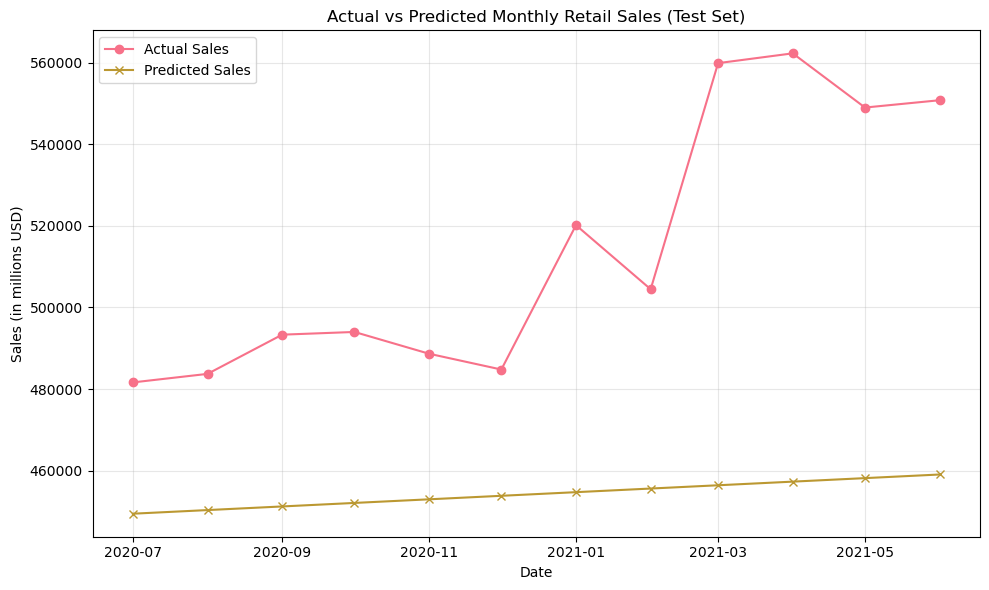

In [45]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Prepare features: use time index as feature
train_df = train_df.sort_values('Date')
test_df = test_df.sort_values('Date')

train_df['TimeIdx'] = (train_df['Date'] - train_df['Date'].min()).dt.days
test_df['TimeIdx'] = (test_df['Date'] - train_df['Date'].min()).dt.days

# Fit linear regression model
lr = LinearRegression()
lr.fit(train_df[['TimeIdx']], train_df['Sales'])

# Predict on test set
test_pred = lr.predict(test_df[['TimeIdx']])
test_df['Predicted_Sales'] = test_pred

# Calculate RMSE
rmse = mean_squared_error(test_df['Sales'], test_df['Predicted_Sales'], squared=False)
print("PREDICTIVE MODEL PERFORMANCE")
print("-" * 80)
print(f"Linear Regression RMSE on test set: {rmse:.2f} million USD")
print()

 

# Plot actual vs predicted sales for test set
plt.figure(figsize=(10, 6))
plt.plot(test_df['Date'], test_df['Sales'], label='Actual Sales', marker='o')
plt.plot(test_df['Date'], test_df['Predicted_Sales'], label='Predicted Sales', marker='x')
plt.title('Actual vs Predicted Monthly Retail Sales (Test Set)')
plt.xlabel('Date')
plt.ylabel('Sales (in millions USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

 

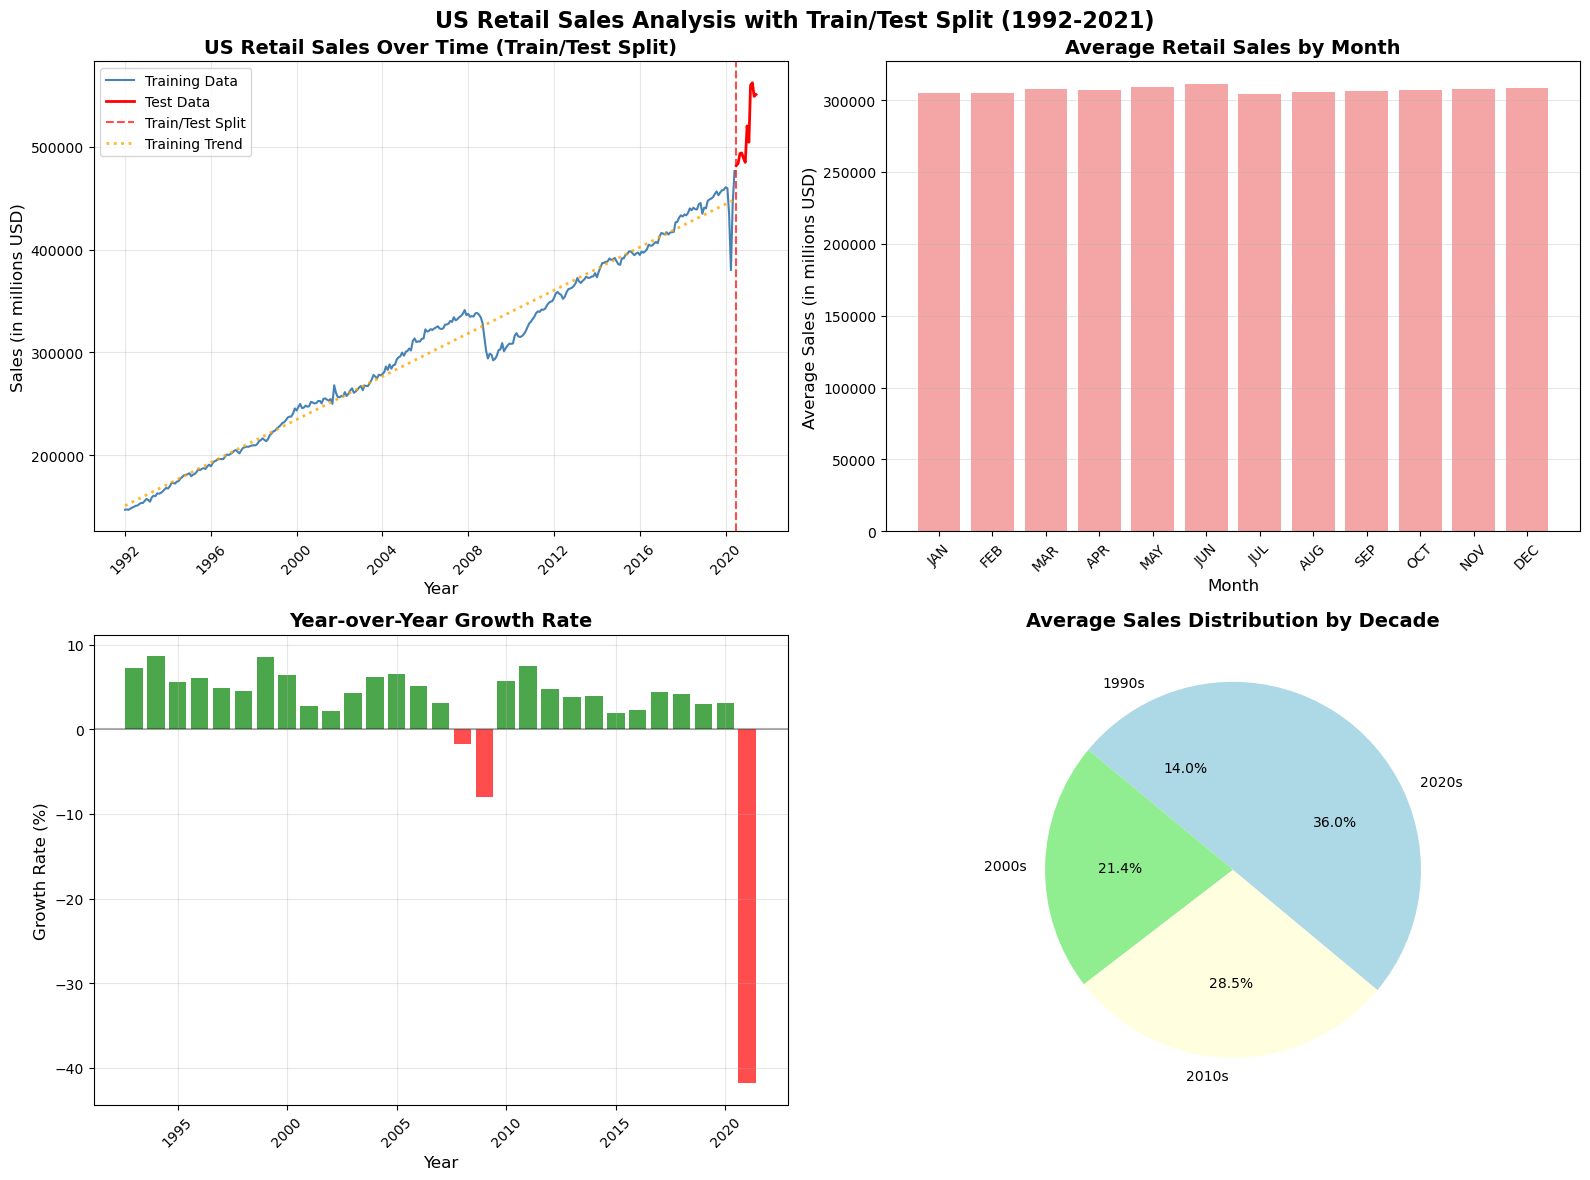

KEY OBSERVATIONS FROM US RETAIL SALES DATA (1992-2021)

1. OVERALL TREND:
   • Total growth from 1992 to 2020: 79.9%
   • Average annual growth rate: 2.9%

2. SEASONAL PATTERNS:
   • Peak sales month: JUN ($311407M average)
   • Lowest sales month: JUL ($304375M average)
   • Seasonal variation: 2.3% from average

3. MAJOR ECONOMIC EVENTS IMPACT:
   • 2008 Financial Crisis: -1.7% growth (recession year)
   • 2009 Recovery: -8.0% growth
   • 2020 COVID-19 Impact: 3.1% growth (pandemic year)

4. VOLATILITY:
   • Standard deviation of growth rates: 9.1%
   • Most volatile year: 2021 (-41.8%)

5. RECENT TRENDS (2015-2020):
   • Average growth rate: 3.1%
   • 2020 showed resilience despite pandemic challenges

6. DATA COMPLETENESS:
   • Data available through June 2021
   • Consistent monthly reporting from 1992-2020


In [46]:
# Create the main plot with train/test visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('US Retail Sales Analysis with Train/Test Split (1992-2021)', fontsize=16, fontweight='bold')
 

# Plot 1: Time series of retail sales with train/test split highlighted
ax1.plot(train_df['Date'], train_df['Sales'], linewidth=1.5, color='steelblue', label='Training Data')
ax1.plot(test_df['Date'], test_df['Sales'], linewidth=2, color='red', label='Test Data')
ax1.axvline(x=test_start_date, color='red', linestyle='--', alpha=0.7, label='Train/Test Split')
ax1.set_title('US Retail Sales Over Time (Train/Test Split)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Sales (in millions USD)', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)
ax1.legend()

# Add trend line for training data only
if len(train_df) > 0:
    z = np.polyfit(range(len(train_df)), train_df['Sales'], 1)
    p = np.poly1d(z)
    ax1.plot(train_df['Date'], p(range(len(train_df))), "orange", alpha=0.8, linewidth=2, linestyle=':', label='Training Trend')
    ax1.legend()

# Plot 2: Seasonal patterns (average by month)
monthly_avg = melted_df.groupby('Month')['Sales'].mean()
month_order = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']

monthly_avg = monthly_avg.reindex(month_order)

ax2.bar(monthly_avg.index, monthly_avg.values, color='lightcoral', alpha=0.7)
ax2.set_title('Average Retail Sales by Month', fontsize=14, fontweight='bold')
ax2.set_xlabel('Month', fontsize=12)
ax2.set_ylabel('Average Sales (in millions USD)', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3, axis='y')


# Plot 3: Year-over-year growth rate
yearly_sales = df.set_index('YEAR')[months].sum(axis=1)
growth_rate = yearly_sales.pct_change() * 100


ax3.bar(growth_rate.index[1:], growth_rate.values[1:],color=['green' if x > 0 else 'red' for x in growth_rate.values[1:]], alpha=0.7)

ax3.set_title('Year-over-Year Growth Rate', fontsize=14, fontweight='bold')
ax3.set_xlabel('Year', fontsize=12)
ax3.set_ylabel('Growth Rate (%)', fontsize=12)
ax3.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis='x', rotation=45)

# Plot 4: Sales distribution by decade
melted_df['Decade'] = (melted_df['Year'] // 10) * 10
decade_sales = melted_df.groupby('Decade')['Sales'].mean()
ax4.pie(decade_sales.values, labels=[f"{int(d)}s" for d in decade_sales.index],
        autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightgreen', 'lightyellow'])

ax4.set_title('Average Sales Distribution by Decade', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Print key observations
print("=" * 60)

print("KEY OBSERVATIONS FROM US RETAIL SALES DATA (1992-2021)")

print("=" * 60)

# Overall trend
total_growth = ((yearly_sales.iloc[-1] - yearly_sales.iloc[0]) / yearly_sales.iloc[0]) * 100

print(f"\n1. OVERALL TREND:")
print(f"   • Total growth from 1992 to 2020: {total_growth:.1f}%")
print(f"   • Average annual growth rate: {total_growth/28:.1f}%")

# Seasonal patterns
peak_month = monthly_avg.idxmax()
low_month = monthly_avg.idxmin()
seasonal_variation = ((monthly_avg.max() - monthly_avg.min()) / monthly_avg.mean()) * 100

print(f"\n2. SEASONAL PATTERNS:")
print(f"   • Peak sales month: {peak_month} (${monthly_avg.max():.0f}M average)")
print(f"   • Lowest sales month: {low_month} (${monthly_avg.min():.0f}M average)")
print(f"   • Seasonal variation: {seasonal_variation:.1f}% from average")

# Economic events impact
print(f"\n3. MAJOR ECONOMIC EVENTS IMPACT:")
print(f"   • 2008 Financial Crisis: {growth_rate.loc[2008]:.1f}% growth (recession year)")
print(f"   • 2009 Recovery: {growth_rate.loc[2009]:.1f}% growth")
print(f"   • 2020 COVID-19 Impact: {growth_rate.loc[2020]:.1f}% growth (pandemic year)")

# Volatility analysis
std_dev = growth_rate.std()

print(f"\n4. VOLATILITY:")
print(f"   • Standard deviation of growth rates: {std_dev:.1f}%")
print(f"   • Most volatile year: {growth_rate.abs().idxmax()} ({growth_rate.loc[growth_rate.abs().idxmax()]:.1f}%)")

# Recent trends
recent_growth = growth_rate.loc[2015:2020].mean()

print(f"\n5. RECENT TRENDS (2015-2020):")
print(f"   • Average growth rate: {recent_growth:.1f}%")
print(f"   • 2020 showed resilience despite pandemic challenges")

 
print(f"\n6. DATA COMPLETENESS:")
print(f"   • Data available through June 2021")
print(f"   • Consistent monthly reporting from 1992-2020")
print("=" * 60)